# Regime Modelling — Analysis Notebook

Two Sigma GMM approach · Bloomberg + Fama-French data

**Run cells top-to-bottom in order. Each section saves its outputs to `outputs/GMM/`.**

## 0. Setup

In [2]:
import sys, os, warnings, time
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')   # safe for all environments; switch to 'inline' in Jupyter
%matplotlib inline

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

OUT_ROOT = ROOT / 'outputs' / 'GMM'
FIG_ROOT = OUT_ROOT / 'figures'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
FIG_ROOT.mkdir(parents=True, exist_ok=True)

## 1. Configure data paths

Set `DATA_ROOT` to the folder containing `Bloomberg_Data/`, `Farma_French/`, `Macro/`.

In [3]:
DATA_ROOT = ROOT / 'Data'

from src import data_loader as dl
dl.DATA_ROOT     = DATA_ROOT
dl.BLOOMBERG_DIR = DATA_ROOT / 'Bloomberg_Data'
dl.MACRO_DIR     = DATA_ROOT / 'Macro'
dl.FF_DIR        = DATA_ROOT / 'Farma_French'

for subdir in ['Bloomberg_Data', 'Farma_French', 'Macro']:
    p = DATA_ROOT / subdir
    status = 'OK' if p.exists() else 'MISSING — update DATA_ROOT'
    print(f'  {subdir:20s}  {status}')

  Bloomberg_Data        OK
  Farma_French          OK
  Macro                 OK


## 2. Load & inspect raw data

In [4]:
from src.data_loader import (
    load_bloomberg_all, load_ff5_daily,
    load_interest_rate_daily, load_cpi_interest_rates,
    ALL_BLOOMBERG_TICKERS,
)

raw_panel = load_bloomberg_all(ALL_BLOOMBERG_TICKERS)
ff5 = load_ff5_daily()
ir  = load_interest_rate_daily()
cpi = load_cpi_interest_rates()

print(f'Bloomberg panel: {raw_panel.shape}')
print(f'FF5 daily:       {ff5.shape}  {ff5.index[0].date()} -> {ff5.index[-1].date()}')
print(f'Interest rates:  {ir.shape}')
print(f'CPI quarterly:   {cpi.shape}')
print()
print('Bloomberg series coverage:')
for col in raw_panel.columns:
    s = raw_panel[col].dropna()
    print(f'  {col:12s}  {len(s):5d} obs  {s.index[0].date()} -> {s.index[-1].date()}')

Bloomberg panel: (17077, 18)
FF5 daily:       (15813, 6)  1963-07-01 -> 2026-04-30
Interest rates:  (25924, 82)
CPI quarterly:   (397, 20)

Bloomberg series coverage:
  MXCXDMHR       6407 obs  1998-12-31 -> 2026-06-01
  LGY7TRUH       6550 obs  1987-06-30 -> 2026-06-01
  LUACTRUU       9582 obs  1973-01-31 -> 2026-06-01
  LF98TRUU       7167 obs  1983-07-29 -> 2026-06-01
  LP05TRUH       6568 obs  1999-01-29 -> 2026-06-01
  LP01TRUH       6600 obs  1999-01-29 -> 2026-06-01
  BCOMTR        16686 obs  1960-01-04 -> 2026-06-02
  MXEF          10023 obs  1987-12-31 -> 2026-06-01
  EMUSTRUU       7434 obs  1993-01-29 -> 2026-06-01
  BCIT5T         7632 obs  1997-02-28 -> 2026-06-01
  PUT           10055 obs  1986-06-30 -> 2026-06-01
  MXWD          10023 obs  1987-12-31 -> 2026-06-01
  LEGATRUU       7216 obs  1990-01-01 -> 2026-06-01
  RU30INTR      11962 obs  1978-12-29 -> 2026-06-01
  SPGSCITR      14219 obs  1970-01-02 -> 2026-06-01
  LBUSTRUU       9540 obs  1976-03-31 -> 2026-06-01
 

## 3. Build clean data panel

Align to business-day calendar, forward-fill gaps, compute log returns.

| Start date | Coverage | Notes |
|-----------|----------|-------|
| `2002-01-02` | All 15 factors daily | **Recommended** |
| `1999-01-04` | Slightly longer, swap MXCXDMHR→MXWD | |
| `1987-07-01` | Longest history, monthly pre-2001 | |

In [5]:
from src.data_cleaner import build_clean_dataset

START_DATE = '2002-01-02'

t0 = time.time()
dataset  = build_clean_dataset(start=START_DATE)
prices   = dataset['prices']
returns  = dataset['returns']
ff5_aln  = dataset['ff5']
rf       = dataset['rf']
calendar = dataset['calendar']
print(f'Built in {time.time()-t0:.1f}s')
print(f'Calendar : {calendar[0].date()} -> {calendar[-1].date()}  ({len(calendar)} days)')
print(f'Returns  : {returns.shape}')
print(f'RF (mean daily): {rf.mean()*100:.5f}%')

ff5.to_csv(OUT_ROOT / 'ff5_daily.csv')
rf.to_csv(OUT_ROOT / 'risk_free_daily.csv')
print(f'Saved: {OUT_ROOT / "ff5_daily.csv"}')
print(f'Saved: {OUT_ROOT / "risk_free_daily.csv"}')

# Save
prices.to_parquet(OUT_ROOT / 'prices.parquet')
returns.to_parquet(OUT_ROOT / 'returns.parquet')
print(f'Saved: {OUT_ROOT / "prices.parquet"}, {OUT_ROOT / "returns.parquet"}')

Built in 7.4s
Calendar : 2002-01-02 -> 2026-06-25  (6387 days)
Returns  : (6374, 18)
RF (mean daily): 0.00713%
Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\ff5_daily.csv
Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\risk_free_daily.csv
Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\prices.parquet, c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\returns.parquet


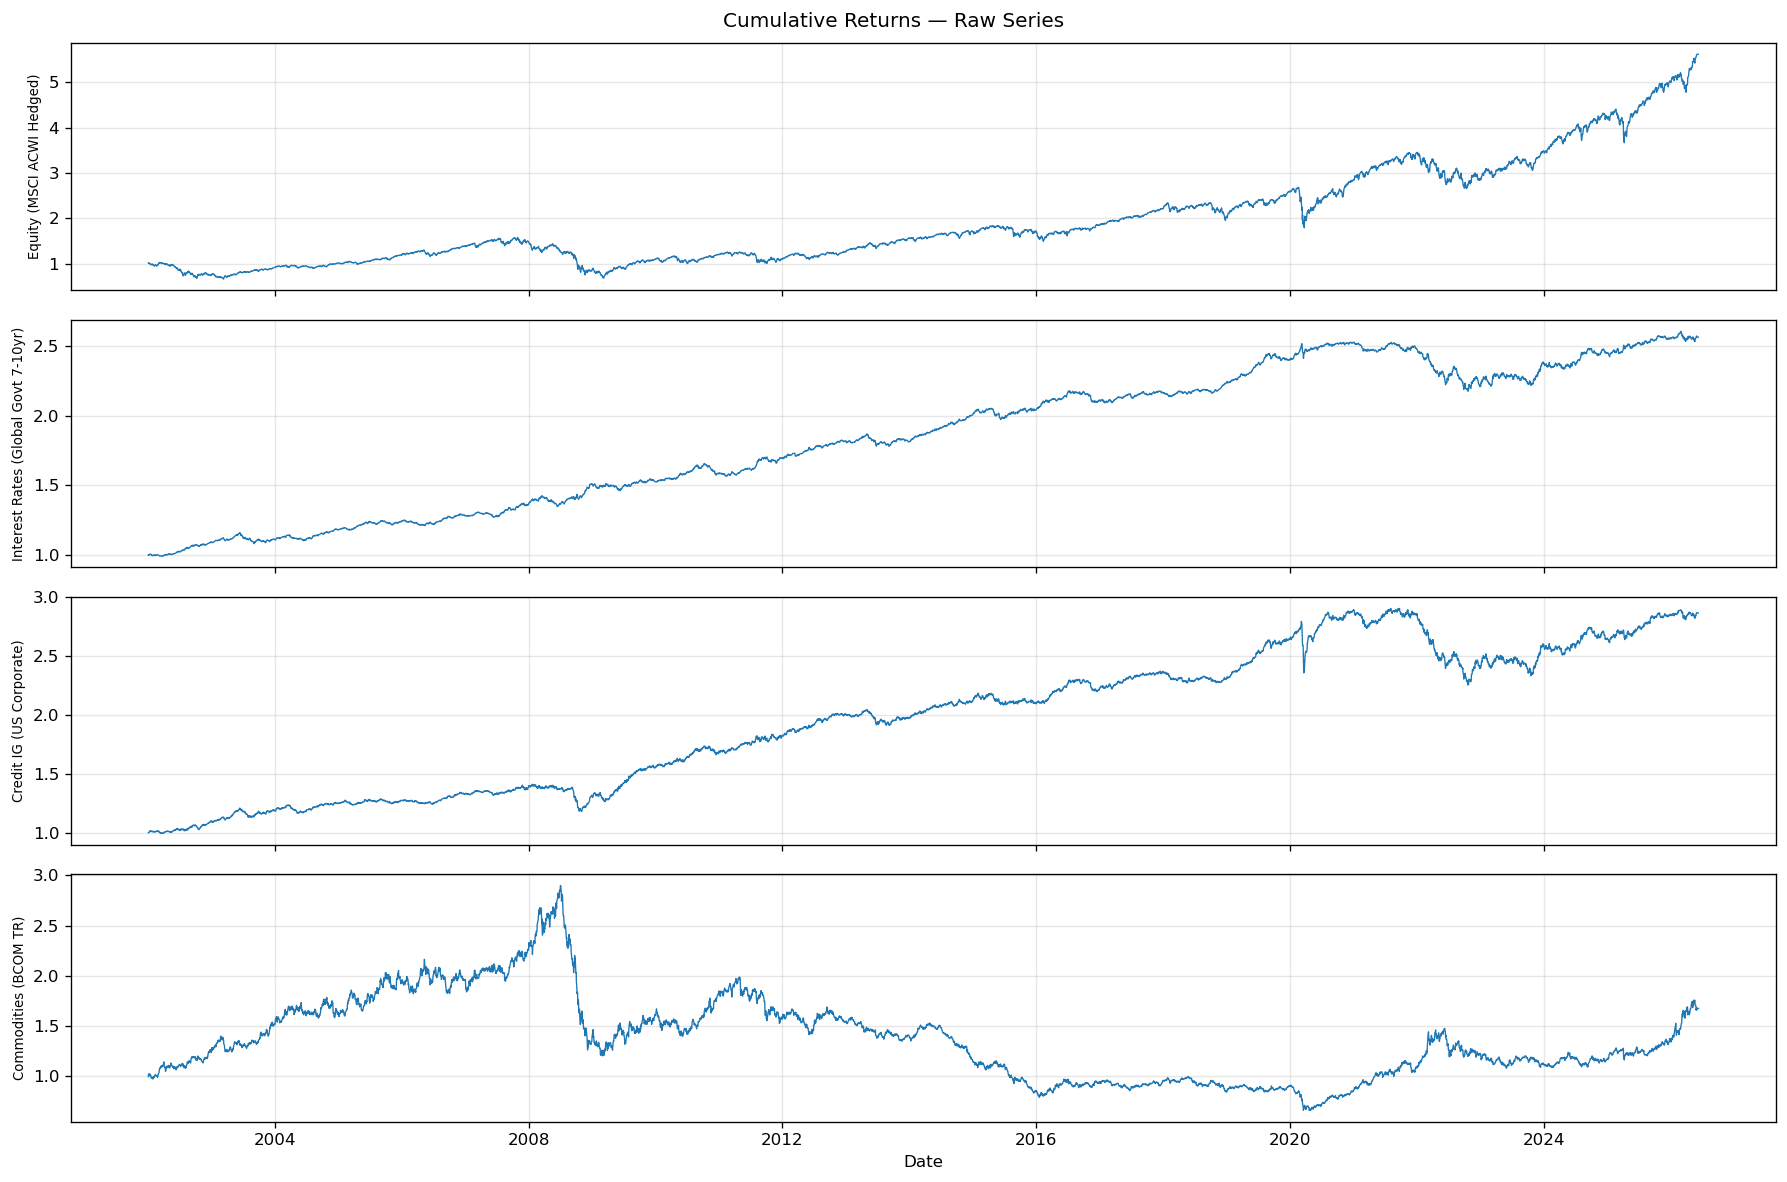

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\01_raw_cumulative_returns.png


In [6]:
# Sanity check: cumulative returns of core series
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
checks = [
    ('MXCXDMHR', 'Equity (MSCI ACWI Hedged)'),
    ('LGY7TRUH', 'Interest Rates (Global Govt 7-10yr)'),
    ('LUACTRUU', 'Credit IG (US Corporate)'),
    ('BCOMTR',   'Commodities (BCOM TR)'),
]
for ax, (col, label) in zip(axes, checks):
    if col in returns.columns:
        cum = (1 + returns[col]).cumprod()
        ax.plot(cum.index, cum.values, linewidth=0.8)
        ax.set_ylabel(label, fontsize=8)
        ax.grid(alpha=0.3)
axes[-1].set_xlabel('Date')
fig.suptitle('Cumulative Returns — Raw Series', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_ROOT / '01_raw_cumulative_returns.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_ROOT / "01_raw_cumulative_returns.png"}')

## 4. Construct factors

Core Macro → Secondary Macro → Style (FF5). Each later group is residualised against all earlier factors (rolling EWM-OLS, 60-day half-life).

In [7]:
from src.factor_construction import build_factor_matrix, get_factor_matrix_for_gmm

t0 = time.time()
factor_matrix = build_factor_matrix(
    start=START_DATE,
    include_style=True,
    halflife_days=60,
    min_periods=126,
    verbose=True,
)
print(f'\nFactor construction: {time.time()-t0:.1f}s')

# Save
factor_matrix.to_parquet(OUT_ROOT / 'factor_matrix.parquet')
print(f'Saved: {OUT_ROOT / "factor_matrix.parquet"}')

[factor_construction] Building factor matrix: 2002-01-02 → today
  Loading raw data...
  Returns panel: 6374 days × 18 series
  FF5 panel:     6387 days × 6 factors
  Building Core Macro factors (Equity, Rates, Credit, Commodities)...
[core_macro] Credit: 4 sub-indices (US IG, US HY, EU IG, EU HY) — EU legs active from mid-2000.
  Core Macro: all 4 factors valid from 2002-12-20
  Building Secondary Macro factors...
[secondary_macro] Foreign_Currency: built successfully.
  Secondary Macro columns: ['Emerging_Markets', 'Foreign_Currency', 'Local_Inflation', 'Short_Volatility', 'Trend_Following', 'Local_Equity']
  Building Style factors (FF5 residualised vs Core Macro)...
  Style columns: ['FF_Market', 'FF_SMB', 'FF_HML', 'FF_RMW', 'FF_CMA']
  After NA filtering (threshold=0.5): 5996 rows kept, 378 dropped
  Factor matrix shape: (5996, 15)
  Date range: 2003-06-16 -> 2026-06-08
  Columns: ['Equity', 'Interest_Rates', 'Credit', 'Commodities', 'Emerging_Markets', 'Foreign_Currency', 'Local_

In [8]:
# Summary statistics
print(f'Factor matrix: {factor_matrix.shape}')
print(f'Date range   : {factor_matrix.index[0].date()} -> {factor_matrix.index[-1].date()}')
print()
ann_mean = factor_matrix.mean() * 252 * 100
ann_vol  = factor_matrix.std()  * (252**0.5) * 100
sharpe   = ann_mean / ann_vol
summary  = pd.DataFrame({'Mean_%': ann_mean, 'Vol_%': ann_vol, 'Sharpe': sharpe})
print(summary.round(3).to_string())
summary.to_csv(OUT_ROOT / 'factor_summary_stats.csv')
print(f'\nSaved: {OUT_ROOT / "factor_summary_stats.csv"}')

Factor matrix: (5996, 15)
Date range   : 2003-06-16 -> 2026-06-08

                  Mean_%   Vol_%  Sharpe
Equity            9.2030 14.3130  0.6430
Interest_Rates    3.3770  3.2320  1.0450
Credit           -0.3750  2.3390 -0.1600
Commodities      -0.4160 14.8920 -0.0280
Emerging_Markets -0.8240  4.8050 -0.1710
Foreign_Currency -0.3240  6.4950 -0.0500
Local_Inflation   0.4980  4.7470  0.1050
Short_Volatility -1.0720  7.0900 -0.1510
Trend_Following   3.3040  4.5400  0.7280
Local_Equity     -0.1330  6.6300 -0.0200
FF_Market        -0.1580  6.8600 -0.0230
FF_SMB            0.1980  9.7100  0.0200
FF_HML           -0.9500 11.0560 -0.0860
FF_RMW            0.0050  6.9260  0.0010
FF_CMA           -0.1540  5.7420 -0.0270

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\factor_summary_stats.csv


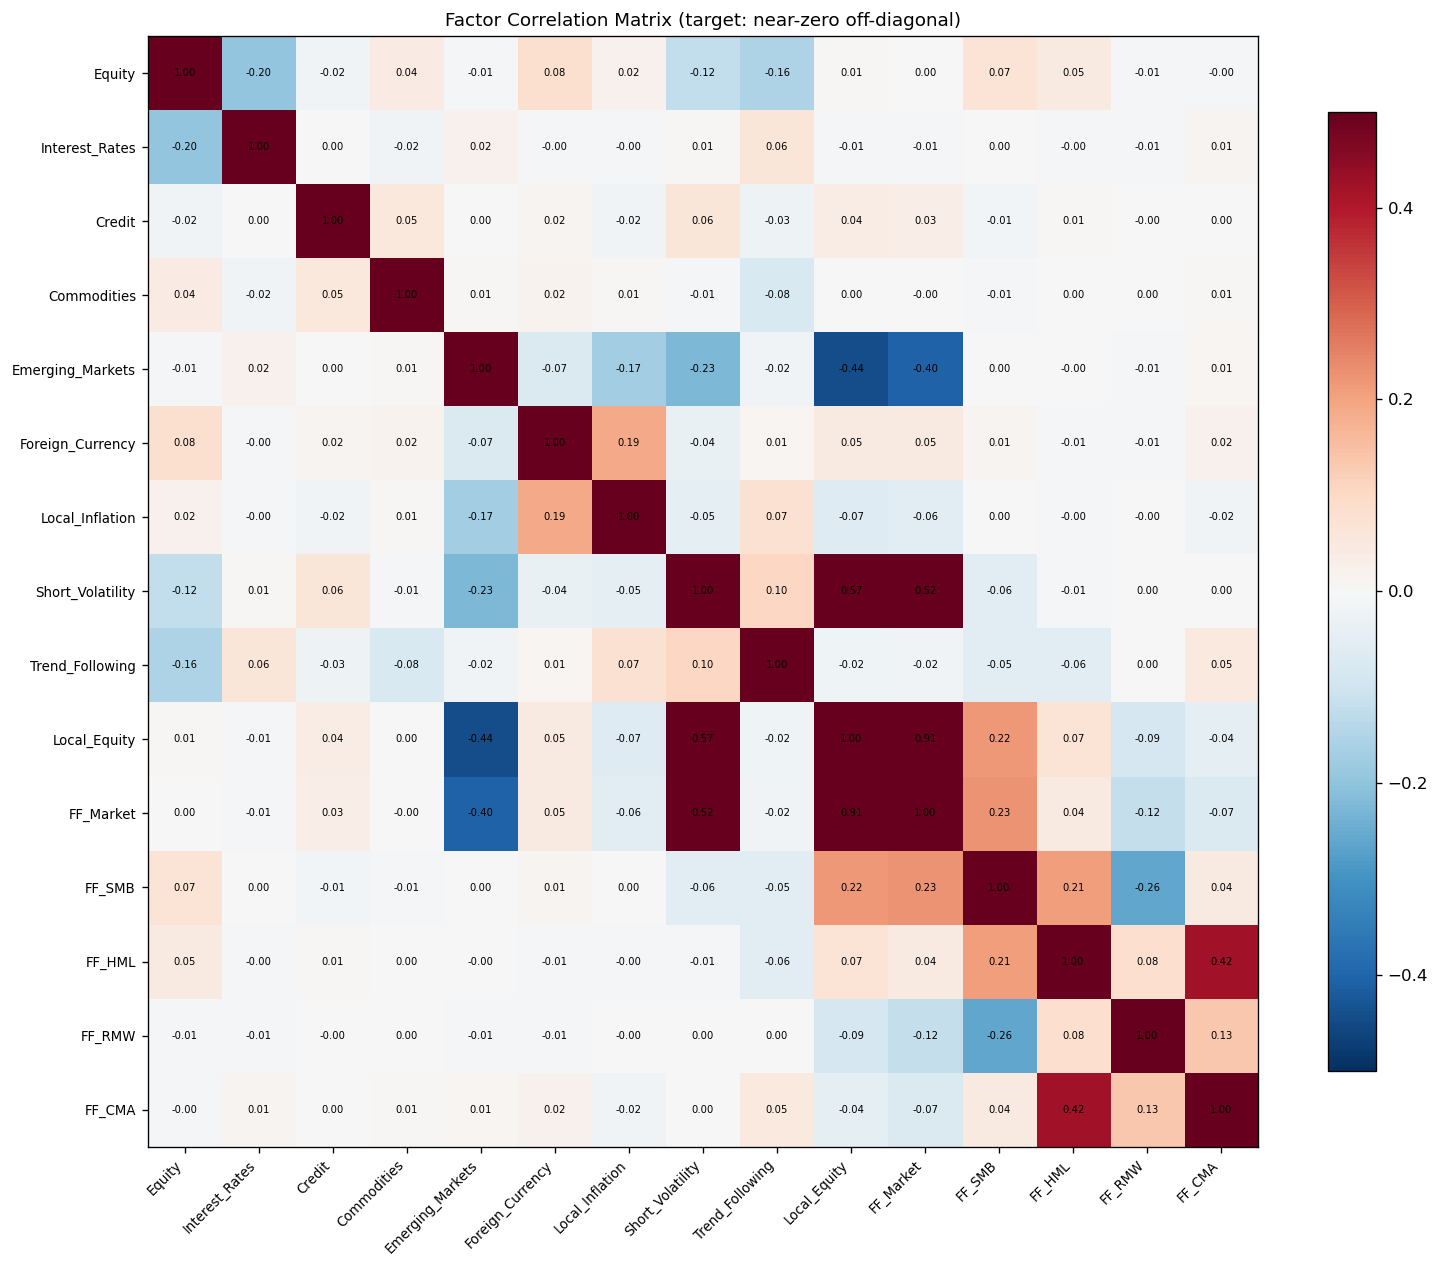

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\02_factor_correlation.png, c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\factor_correlation.csv


In [9]:
# Factor correlation matrix (orthogonality check — should be near-zero off-diagonal)
corr = factor_matrix.dropna().corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title('Factor Correlation Matrix (target: near-zero off-diagonal)', fontsize=11)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(FIG_ROOT / '02_factor_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
corr.to_csv(OUT_ROOT / 'factor_correlation.csv')
print(f'Saved: {FIG_ROOT / "02_factor_correlation.png"}, {OUT_ROOT / "factor_correlation.csv"}')

## 5. Prepare GMM input matrix

`get_factor_matrix_for_gmm` drops any remaining NaN rows (from the burn-in period). This is the matrix fed directly into the GMM — keep it as `X` for all subsequent steps.

In [10]:
X = get_factor_matrix_for_gmm(factor_matrix, dropna=True)
print(f'GMM input X: {X.shape}')
print(f'Date range : {X.index[0].date()} -> {X.index[-1].date()}')
print(f'Dropped    : {len(factor_matrix) - len(X)} rows (NaN burn-in)')

X.to_parquet(OUT_ROOT / 'gmm_input_X.parquet')
print(f'Saved: {OUT_ROOT / "gmm_input_X.parquet"}')

GMM input X: (5974, 15)
Date range : 2003-06-16 -> 2026-05-07
Dropped    : 22 rows (NaN burn-in)
Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\gmm_input_X.parquet


## 6. Fit the GMM regime model

**Option A** (`run_cv=False`, `n_components=4`): directly reproduces the Two Sigma four-regime result. Runs in ~30 seconds.

**Option B** (`run_cv=True`): cross-validates over n=2..6 and uses elbow detection to pick the optimal number. Adds ~2–3 minutes. Use the CV plot to sanity-check the selection.

In [11]:
from src.regime_model import fit_regime_model, predict_current_regime

t0 = time.time()
model = fit_regime_model(
    X,
    n_components=4,        # ← change to None and run_cv=True to auto-select
    n_components_range=range(2, 7),
    n_init=20,
    cv_splits=5,
    run_cv=False,          # ← set True to run cross-validation (~2-3 min extra)
    verbose=True,
)
print(f'\nGMM fitting: {time.time()-t0:.1f}s')

# Save probabilities and labels immediately
model.probabilities.to_parquet(OUT_ROOT / 'regime_probabilities.parquet')
model.hard_labels.rename('regime_int').to_frame().to_parquet(OUT_ROOT / 'regime_hard_labels.parquet')
print(f'Saved: {OUT_ROOT / "regime_probabilities.parquet"}')
print(f'Saved: {OUT_ROOT / "regime_hard_labels.parquet"}')

[regime_model] Fitting GMM on 5974 obs × 15 factors
  Fitting final GMM with n_components=4, n_init=20...
  GMM converged: True

  Annualised factor means per regime (%):
    Equity  Interest_Rates   Credit  Commodities  Emerging_Markets  Foreign_Currency  Local_Inflation  Short_Volatility  Trend_Following  Local_Equity  FF_Market  FF_SMB  FF_HML   FF_RMW   FF_CMA
0  27.2500          3.4300   1.3500       0.1800            2.7700           -1.6000          -0.9800           -0.0800           2.9300       -1.8700    -3.8900 -4.0800 -2.6200   0.1700  -0.6400
1  16.0200         -0.2500  -0.4300      -5.9700           -1.9600            2.6500           2.2000          -11.0400           2.4500      -16.2400    14.7700 18.2000  4.1600 -17.4700   1.0000
2  -5.5200          1.8500  -0.9900       6.6800           -5.2000            1.6800           2.2500            3.3300           3.7300        3.2100     1.3700  0.1500  2.0800   3.0200   3.3400
3 -71.5800         15.9300 -13.0500     -48.5

In [12]:
# CV score plot (only populated when run_cv=True)
from src.regime_utils import plot_cv_scores
if model.cv_scores:
    fig = plot_cv_scores(model.cv_scores)
    fig.savefig(FIG_ROOT / '03_cv_scores.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_ROOT / "03_cv_scores.png"}')
else:
    print('CV not run (run_cv=False). Set run_cv=True above to generate this plot.')
print(f'n_components = {model.n_components}')

CV not run (run_cv=False). Set run_cv=True above to generate this plot.
n_components = 4


## 7. Label regimes

The auto-labeller applies Two Sigma heuristics (most-negative equity = Crisis, highest Local Inflation = Inflation, highest equity vol among positive-return regimes = WOI). **Always verify against the heatmap below and override if needed.**

In [13]:
from src.regime_utils import compute_regime_stats, plot_factor_heatmap, relabel_regimes

# compute_regime_stats aligns factor_matrix and hard_labels on common index automatically
means_df, vols_df = compute_regime_stats(factor_matrix, model.hard_labels, model.regime_names)

print('Auto-assigned labels:', model.regime_names)
print()
print('Annualised factor means by regime (%):')
print((means_df * 100).round(2).to_string())

means_df.to_csv(OUT_ROOT / 'regime_factor_means.csv')
vols_df.to_csv(OUT_ROOT / 'regime_factor_vols.csv')
print(f'\nSaved: {OUT_ROOT / "regime_factor_means.csv"}, {OUT_ROOT / "regime_factor_vols.csv"}')

Auto-assigned labels: {3: 'Crisis', 0: 'Steady_State', 2: 'WOI', 1: 'Inflation'}

Annualised factor means by regime (%):
               Equity  Interest_Rates   Credit  Commodities  Emerging_Markets  Foreign_Currency  Local_Inflation  Short_Volatility  Trend_Following  Local_Equity  FF_Market  FF_SMB  FF_HML   FF_RMW   FF_CMA
Crisis       -71.5800         15.9300 -13.0500     -48.5900           -4.2800           -2.2800           1.7600          -35.5600           4.6400        3.3000    16.5900 31.3000 -8.7700 -11.6500 -20.4400
Steady_State  27.2500          3.4300   1.3500       0.1800            2.7700           -1.6000          -0.9800           -0.0800           2.9300       -1.8700    -3.8900 -4.0800 -2.6200   0.1700  -0.6400
WOI           -5.5200          1.8500  -0.9900       6.6800           -5.2000            1.6800           2.2500            3.3300           3.7300        3.2100     1.3700  0.1500  2.0800   3.0200   3.3400
Inflation     16.0200         -0.2500  -0.4300     

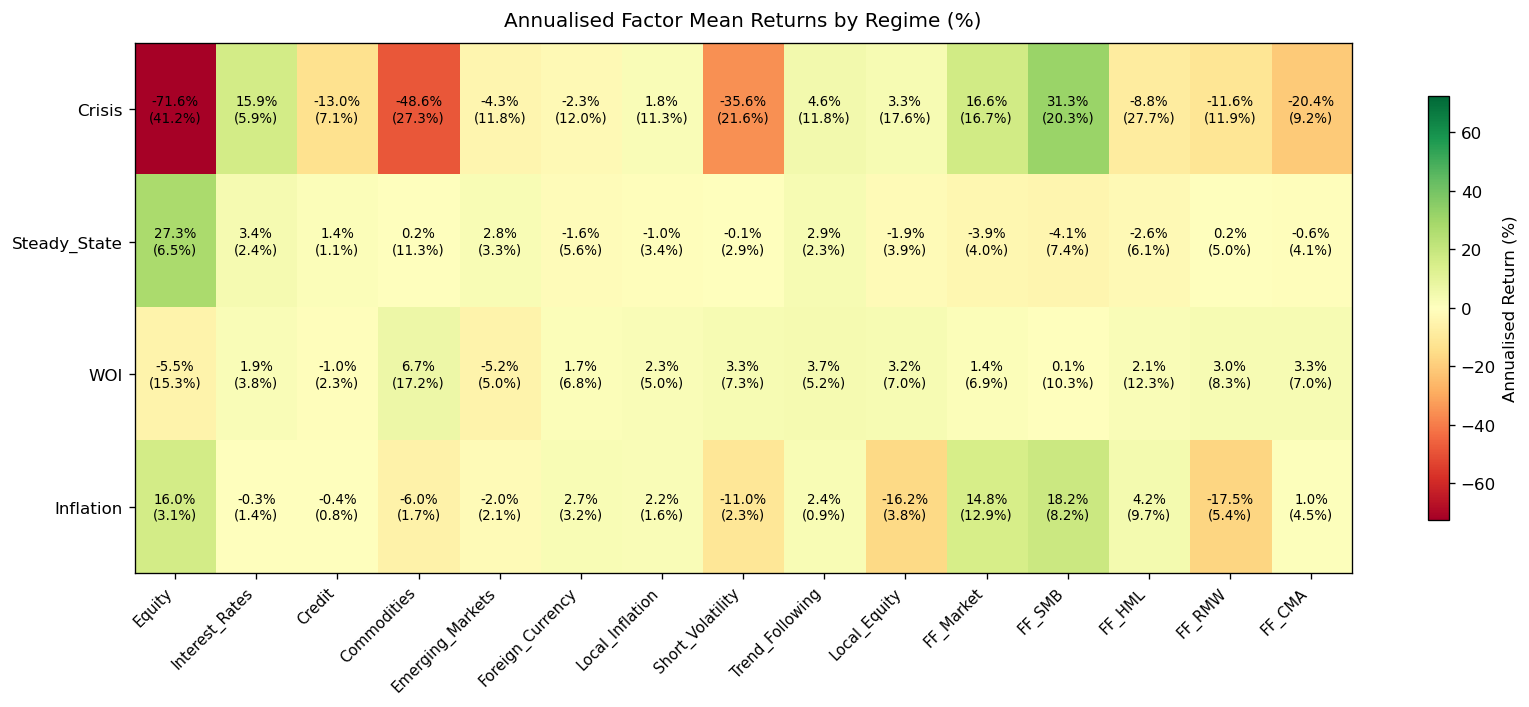

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\04_factor_heatmap.png


In [14]:
fig = plot_factor_heatmap(
    means_df, vols_df,
    title='Annualised Factor Mean Returns by Regime (%)'
)
fig.savefig(FIG_ROOT / '04_factor_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_ROOT / "04_factor_heatmap.png"}')

In [15]:
# ── MANUAL RELABELLING ────────────────────────────────────────────────
# After inspecting the heatmap, override labels if the auto-labeller got any wrong.
# Map each cluster INDEX (integer) to a name string.
#
# Example for 4 components — adjust indices based on your heatmap:
# model = relabel_regimes(model, {
#     0: 'Crisis',
#     1: 'Steady_State',
#     2: 'Inflation',
#     3: 'WOI',
# })
#
# Recompute stats after relabelling:
# means_df, vols_df = compute_regime_stats(factor_matrix, model.hard_labels, model.regime_names)

print('Current labels:', model.regime_names)

# Save named labels
named_labels = model.hard_labels.map(model.regime_names)
named_labels.name = 'regime'
named_labels.to_frame().to_parquet(OUT_ROOT / 'regime_named_labels.parquet')
named_labels.to_frame().to_csv(OUT_ROOT / 'regime_named_labels.csv')
print(f'Saved: {OUT_ROOT / "regime_named_labels.parquet"}, {OUT_ROOT / "regime_named_labels.csv"}')

Current labels: {3: 'Crisis', 0: 'Steady_State', 2: 'WOI', 1: 'Inflation'}
Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\regime_named_labels.parquet, c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\regime_named_labels.csv


## 8. Historical regime analysis

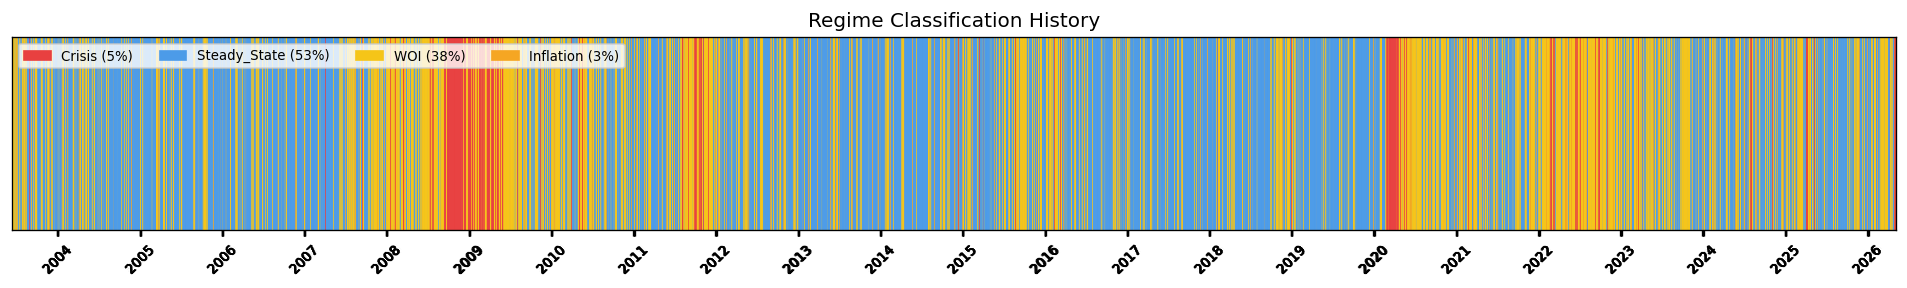

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\05_regime_timeline.png


In [16]:
from src.regime_utils import plot_regime_timeline, plot_regime_probabilities, get_regime_periods

fig = plot_regime_timeline(
    model.hard_labels, model.regime_names,
    title='Regime Classification History', figsize=(16, 2.5)
)
fig.savefig(FIG_ROOT / '05_regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_ROOT / "05_regime_timeline.png"}')

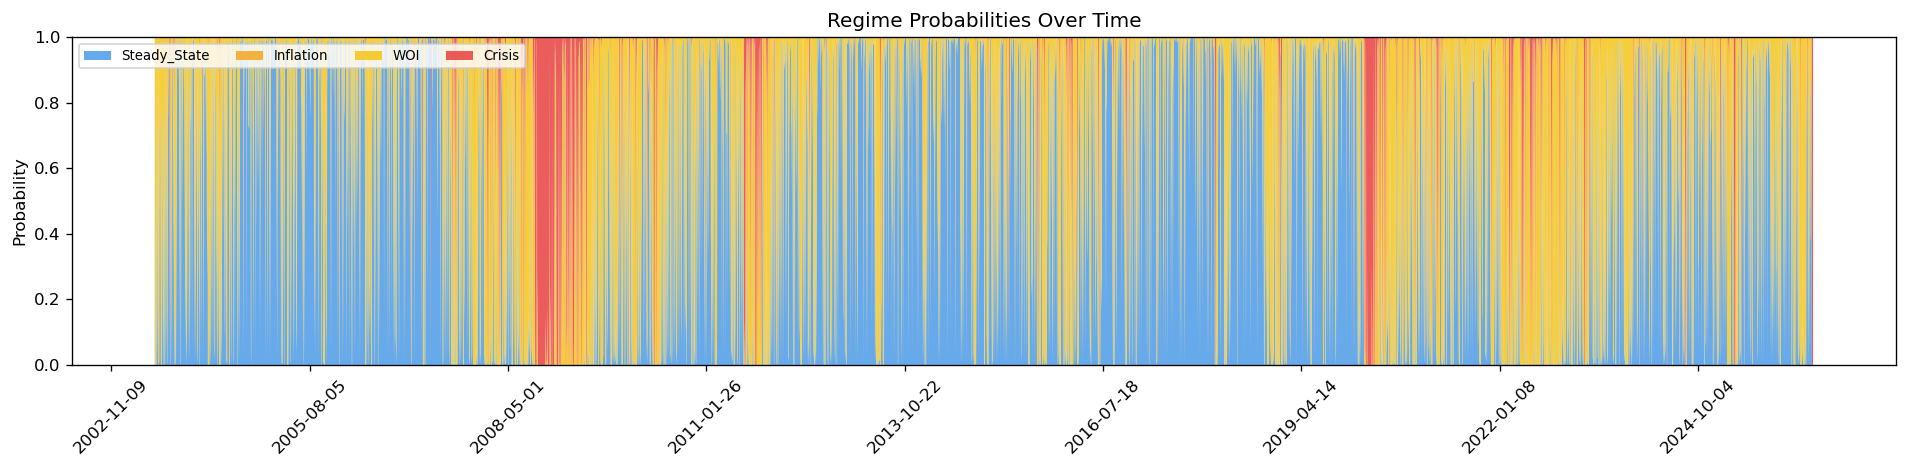

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\06_regime_probabilities.png


In [17]:
fig = plot_regime_probabilities(
    model.probabilities, model.regime_names,
    title='Regime Probabilities Over Time', figsize=(16, 4)
)
fig.savefig(FIG_ROOT / '06_regime_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_ROOT / "06_regime_probabilities.png"}')

In [18]:
freq = model.hard_labels.value_counts().sort_index()
print('Regime frequency:')
rows = []
for k, cnt in freq.items():
    pct   = 100 * cnt / len(model.hard_labels)
    label = model.regime_names.get(k, f'Regime_{k}')
    print(f'  {label:20s}  {cnt:5d} days  ({pct:.1f}%)')
    rows.append({'regime': label, 'days': cnt, 'pct': round(pct, 2)})
freq_df = pd.DataFrame(rows)
freq_df.to_csv(OUT_ROOT / 'regime_frequency.csv', index=False)
print(f'\nSaved: {OUT_ROOT / "regime_frequency.csv"}')

periods = get_regime_periods(model.hard_labels, model.regime_names)
print(f'{len(periods)} contiguous regime periods (first 20):')
print(periods.head(20).to_string(index=False))

periods.to_csv(OUT_ROOT / 'regime_periods.csv', index=False)
print(f'\nSaved: {OUT_ROOT / "regime_periods.csv"}')

Regime frequency:
  Steady_State           3188 days  (53.4%)
  Inflation               202 days  (3.4%)
  WOI                    2259 days  (37.8%)
  Crisis                  325 days  (5.4%)

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\regime_frequency.csv
2329 contiguous regime periods (first 20):
      regime      start        end
         WOI 2003-06-16 2003-06-17
Steady_State 2003-06-17 2003-06-18
         WOI 2003-06-18 2003-06-24
Steady_State 2003-06-24 2003-06-25
         WOI 2003-06-25 2003-06-30
Steady_State 2003-06-30 2003-07-01
         WOI 2003-07-01 2003-07-04
   Inflation 2003-07-04 2003-07-07
         WOI 2003-07-07 2003-07-08
Steady_State 2003-07-08 2003-07-09
         WOI 2003-07-09 2003-07-11
Steady_State 2003-07-11 2003-07-15
         WOI 2003-07-15 2003-07-16
Steady_State 2003-07-16 2003-07-17
         WOI 2003-07-17 2003-07-22
Steady_State 2003-07-22 2003-07-25
         WOI 2003-07-25 2003-07-28
Steady_State 2003-07-28 2

## 9. Transition matrix

In [19]:
from src.regime_utils import compute_transition_matrix

trans = compute_transition_matrix(model.hard_labels, model.regime_names)
print('Regime transition probabilities (%):')
print((trans * 100).round(1).to_string())

trans.to_csv(OUT_ROOT / 'regime_transition_matrix.csv')
print(f'\nSaved: {OUT_ROOT / "regime_transition_matrix.csv"}')

Regime transition probabilities (%):
              Steady_State  Inflation     WOI  Crisis
Steady_State       69.9000     4.8000 24.7000  0.6000
Inflation          54.5000     1.0000 38.1000  6.4000
WOI                37.1000     1.9000 55.3000  5.7000
Crisis              4.0000     1.2000 43.8000 50.9000

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\regime_transition_matrix.csv


## 10. Current regime — "Where are we now?"

In [20]:
# Uses factor_matrix (with NaN) — predict_current_regime calls dropna() internally
current = predict_current_regime(model, factor_matrix, window_days=60)
print('Current regime probabilities (last 60 days):')
print(current.to_string())

recent = factor_matrix.tail(252).mean() * 252 * 100
print()
print('Factor returns (ann. %, trailing 1yr):')
print(recent.sort_values(ascending=False).round(2).to_string())

current.to_frame('probability').to_csv(OUT_ROOT / 'current_regime.csv')
print(f'\nSaved: {OUT_ROOT / "current_regime.csv"}')

Current regime probabilities (last 60 days):
Crisis         1.0000
Inflation      0.0000
WOI            0.0000
Steady_State   0.0000

Factor returns (ann. %, trailing 1yr):
Equity             26.7300
FF_SMB             12.2900
Trend_Following     5.6700
FF_HML              4.3500
FF_CMA              3.8000
Commodities         2.8400
Interest_Rates      2.0300
Local_Inflation     1.3300
FF_Market           1.0700
Emerging_Markets    0.0800
Credit             -0.9300
Short_Volatility   -1.3700
Local_Equity       -1.7600
Foreign_Currency   -3.2900
FF_RMW             -6.9800

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\current_regime.csv


## 11. Full dashboard

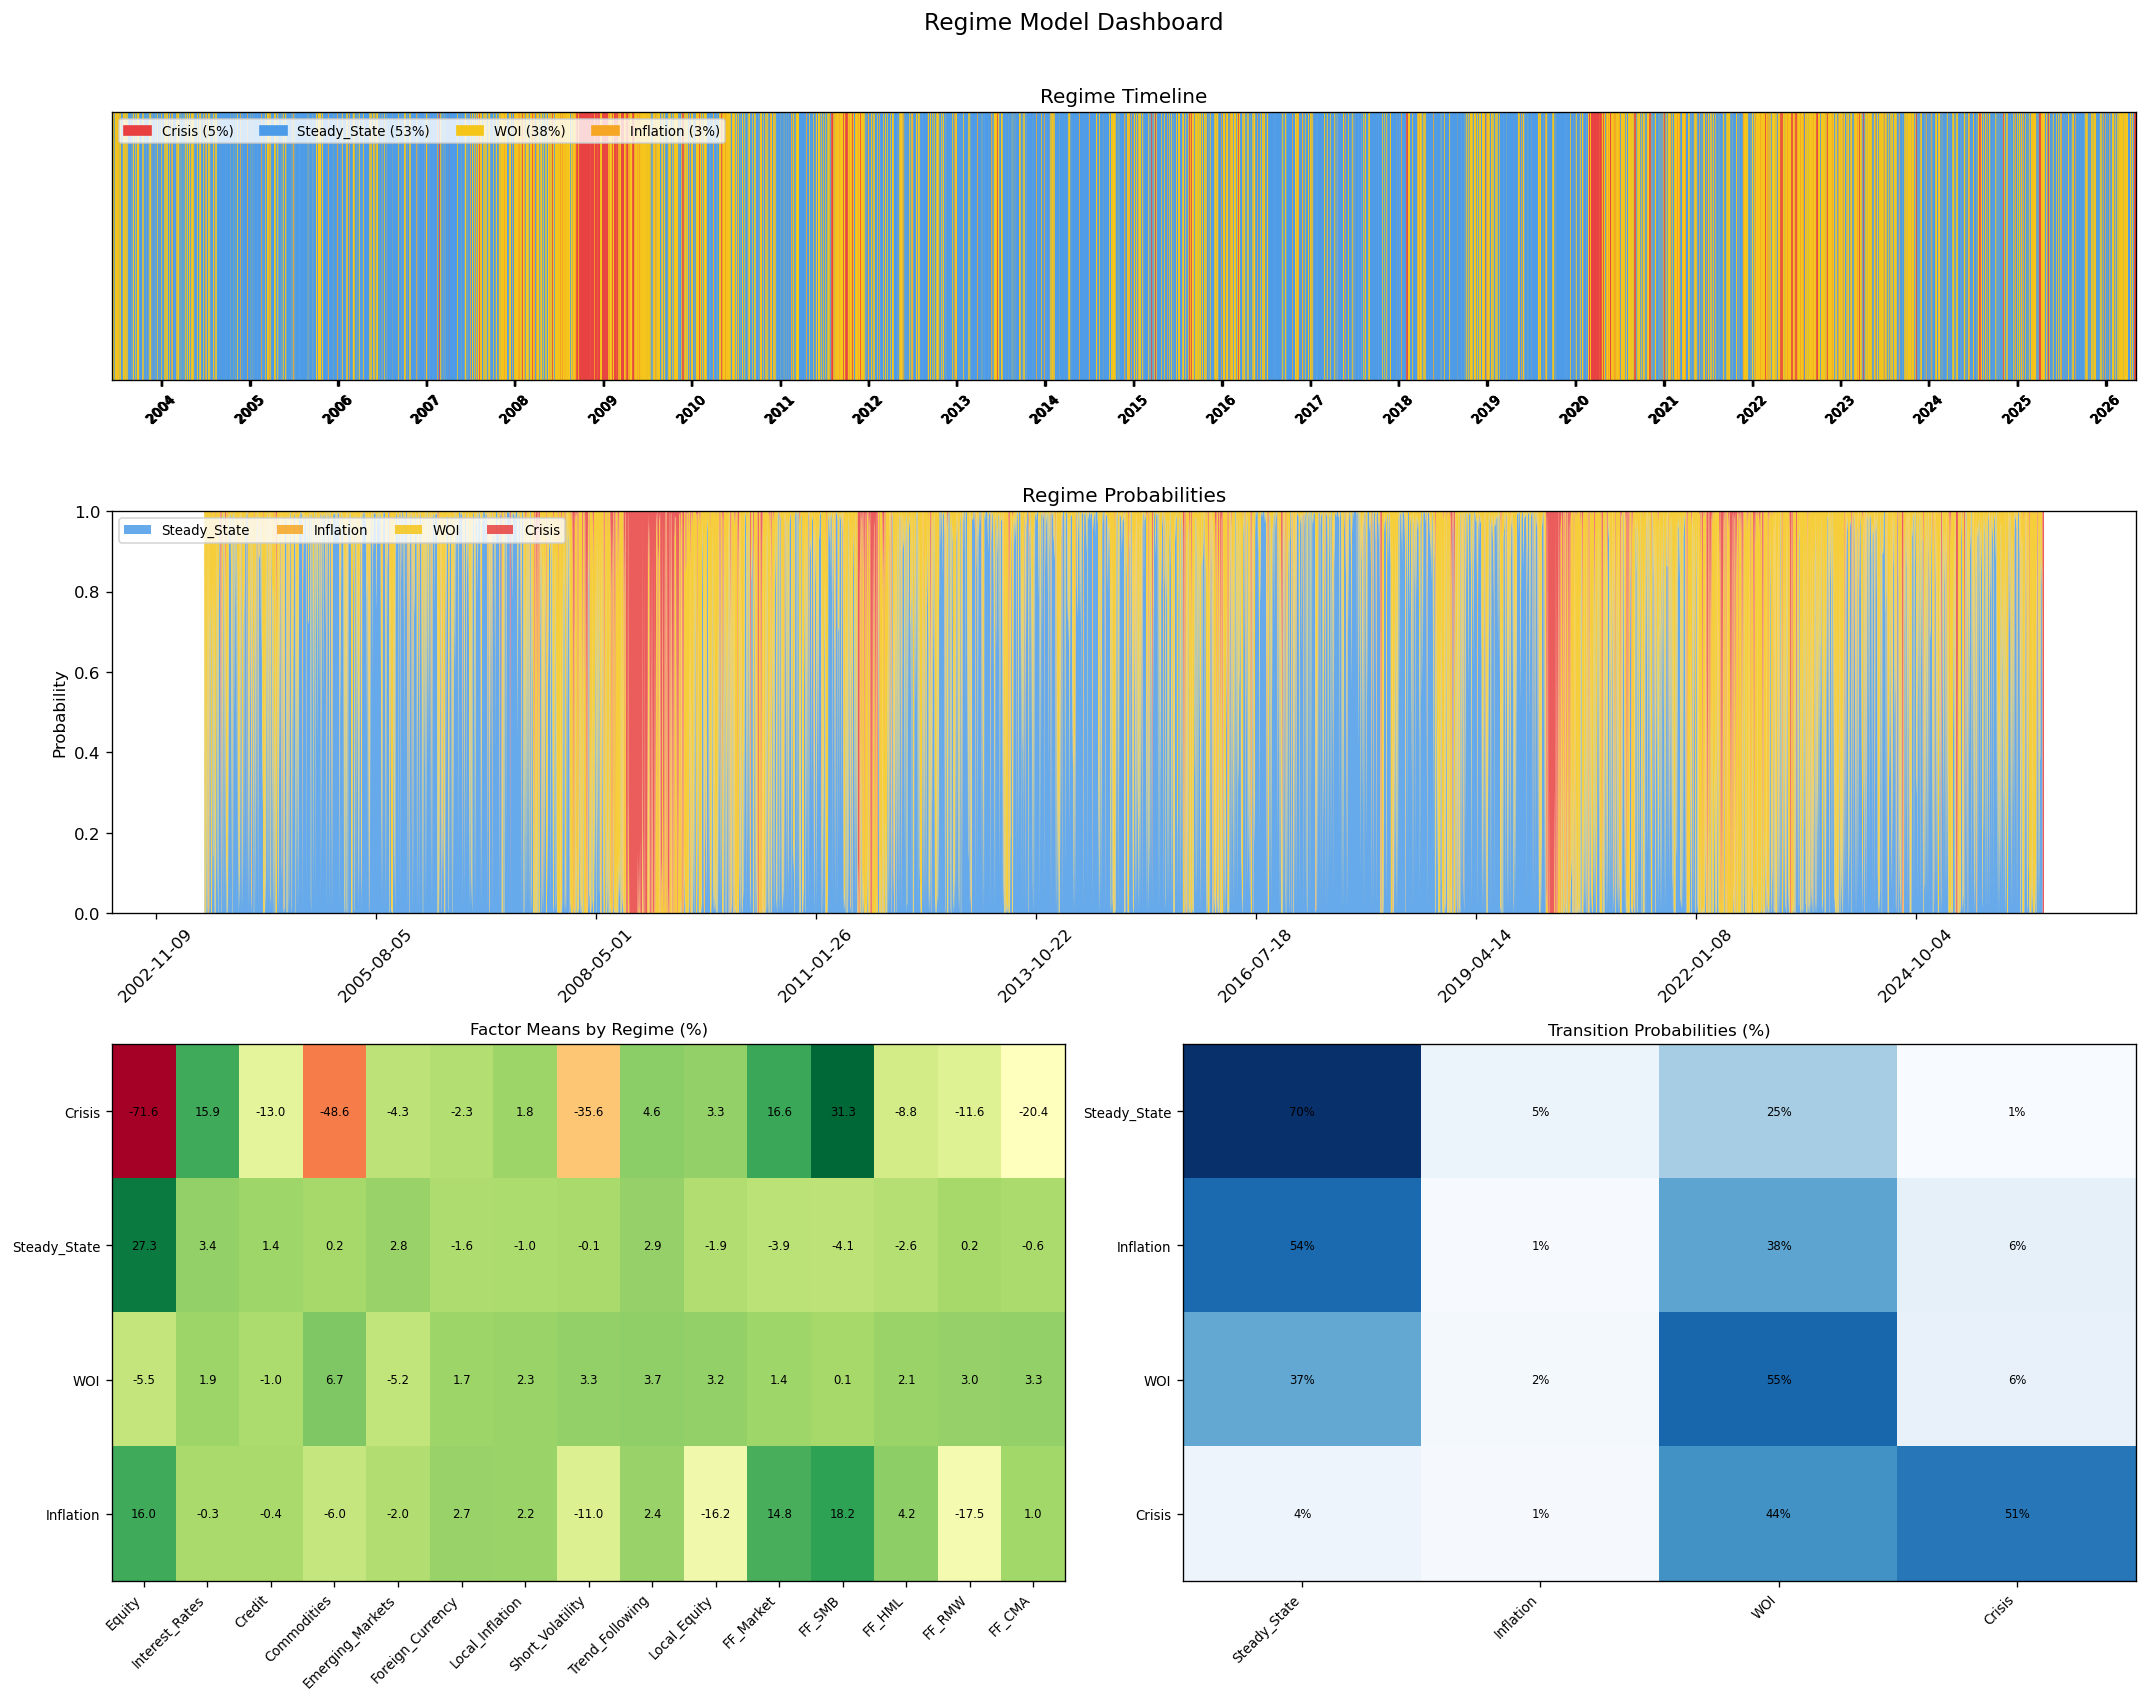

Saved: c:\Users\TanFamily4\Desktop\Github\0_Working_Folders\RegimeModelling\outputs\GMM\figures\07_dashboard.png


In [21]:
from src.regime_utils import plot_dashboard
fig = plot_dashboard(model, factor_matrix, figsize=(18, 14))
fig.savefig(FIG_ROOT / '07_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_ROOT / "07_dashboard.png"}')

## 12. Walk-forward stability (optional — slow)

Re-fits the GMM on rolling 5-year windows to check regime-label consistency. Uncomment to run — expect 10–20 minutes.

In [22]:
# from regime_utils import rolling_regime_window
#
# t0 = time.time()
# rolling_probs = rolling_regime_window(
#     X, n_components=model.n_components,
#     train_years=5, step_months=3, n_init=10, verbose=True,
# )
# print(f'Walk-forward: {time.time()-t0:.0f}s')
# rolling_probs.to_parquet(OUT_ROOT / 'rolling_regime_probs.parquet')
# print(f'Saved: {OUT_ROOT / "rolling_regime_probs.parquet"}')
print('Walk-forward disabled. Uncomment the block above to run.')

Walk-forward disabled. Uncomment the block above to run.


## 13. Output summary

All files saved to `outputs/GMM/`:

| File | Contents |
|------|----------|
| `prices.parquet` | Aligned daily price panel |
| `returns.parquet` | Daily log-return panel |
| `factor_matrix.parquet` | Full 15-factor return matrix (with NaN burn-in) |
| `gmm_input_X.parquet` | Clean factor matrix fed into GMM (no NaN) |
| `regime_probabilities.parquet` | P(regime_k \| day_t) for all k, t |
| `regime_hard_labels.parquet` | Integer cluster label per day |
| `regime_named_labels.parquet/.csv` | Named label per day (e.g. 'Crisis') |
| `regime_frequency.csv` | Days and percentages per regime |
| `regime_factor_means.csv` | Annualised mean return per factor per regime |
| `regime_factor_vols.csv` | Annualised vol per factor per regime |
| `regime_periods.csv` | Start/end dates of each contiguous regime period |
| `regime_transition_matrix.csv` | Transition probability matrix |
| `current_regime.csv` | Latest regime probabilities |
| `factor_summary_stats.csv` | Mean/vol/Sharpe per factor |
| `factor_correlation.csv` | Factor correlation matrix |
| `figures/` | All plots as PNG |

**Next step:** load `regime_probabilities.parquet` into the trading module to build regime-conditional signals.

In [23]:
# Verify all outputs were created
import os
print(f'{OUT_ROOT.relative_to(ROOT)} contents:')
for f in sorted(os.listdir(OUT_ROOT)):
    full = os.path.join(OUT_ROOT, f)
    if os.path.isfile(full):
        size_kb = os.path.getsize(full) / 1024
        print(f'  {f:45s}  {size_kb:7.1f} KB')
print()
print(f'{FIG_ROOT.relative_to(ROOT)} contents:')
for f in sorted(os.listdir(FIG_ROOT)):
    full = os.path.join(FIG_ROOT, f)
    if os.path.isfile(full):
        size_kb = os.path.getsize(full) / 1024
        print(f'  {f:45s}  {size_kb:7.1f} KB')

outputs\GMM contents:
  current_regime.csv                                 0.1 KB
  factor_correlation.csv                             4.7 KB
  factor_matrix.parquet                            906.7 KB
  factor_summary_stats.csv                           1.1 KB
  ff5_daily.csv                                   1080.8 KB
  gmm_input_X.parquet                              904.5 KB
  prices.parquet                                   755.3 KB
  regime_factor_means.csv                            1.4 KB
  regime_factor_vols.csv                             1.4 KB
  regime_frequency.csv                               0.1 KB
  regime_hard_labels.parquet                        55.8 KB
  regime_named_labels.csv                          123.5 KB
  regime_named_labels.parquet                       55.7 KB
  regime_periods.csv                                71.5 KB
  regime_probabilities.parquet                     272.4 KB
  regime_transition_matrix.csv                       0.4 KB
  returns.parquet 